In [3]:
%pip install -q catboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from sklearn.datasets import fetch_openml

porto = fetch_openml(
    data_id=42742,
    as_frame=True,
    parser="auto"
)

X = porto.data.copy()
y = porto.target.copy()

print(X.shape)
print(y.shape)
print(X.head())
print(y.value_counts())

(595212, 57)
(595212,)
   ps_ind_01 ps_ind_02_cat  ps_ind_03 ps_ind_04_cat ps_ind_05_cat  \
0        2.0             2        5.0             1             0   
1        1.0             1        7.0             0             0   
2        5.0             4        9.0             1             0   
3        0.0             1        2.0             0             0   
4        0.0             2        0.0             1             0   

  ps_ind_06_bin ps_ind_07_bin ps_ind_08_bin ps_ind_09_bin ps_ind_10_bin  ...  \
0             0             1             0             0             0  ...   
1             0             0             1             0             0  ...   
2             0             0             1             0             0  ...   
3             1             0             0             0             0  ...   
4             1             0             0             0             0  ...   

  ps_calc_11 ps_calc_12 ps_calc_13  ps_calc_14  ps_calc_15_bin ps_calc_16_bin  \


## Erste Untersuchung

In [5]:
import numpy as np
import pandas as pd

y = pd.to_numeric(y, errors="raise").astype(int)

print("Shape:", X.shape)

print("\nTarget:")
print(y.value_counts())

print("\nTarget in Prozent:")
print(y.value_counts(normalize=True) * 100)

print("\nDatentypen:")
print(X.dtypes.value_counts())

print("\nFehlende Werte:")
print(X.isna().sum().sort_values(ascending=False).head(20))

Shape: (595212, 57)

Target:
target
0    573518
1     21694
Name: count, dtype: int64

Target in Prozent:
target
0    96.355248
1     3.644752
Name: proportion, dtype: float64

Datentypen:
float64     26
category    23
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

Fehlende Werte:
ps_car_03_cat    411231
ps_car_05_cat    266551
ps_reg_03        107772
ps_car_14         42620
ps_car_07_cat     11489
ps_ind_05_cat      5809
ps_car_09_cat       569
ps_ind_02_cat       216
ps_car_01_cat       107
ps_ind_04_cat        83
ps_car_02_cat         5
ps_car_11             5
ps_car_12             1
ps_car_15             0
ps_calc_01            0
ps_calc_04            0
ps_calc_02            0
ps_calc_03            0
ps_ind_01             0
ps_calc_05            0
dtype: int64


In [6]:
y.value_counts(normalize=True)

target
0    0.963552
1    0.036448
Name: proportion, dtype: float64

## Visualisierung der Klassenverteilung

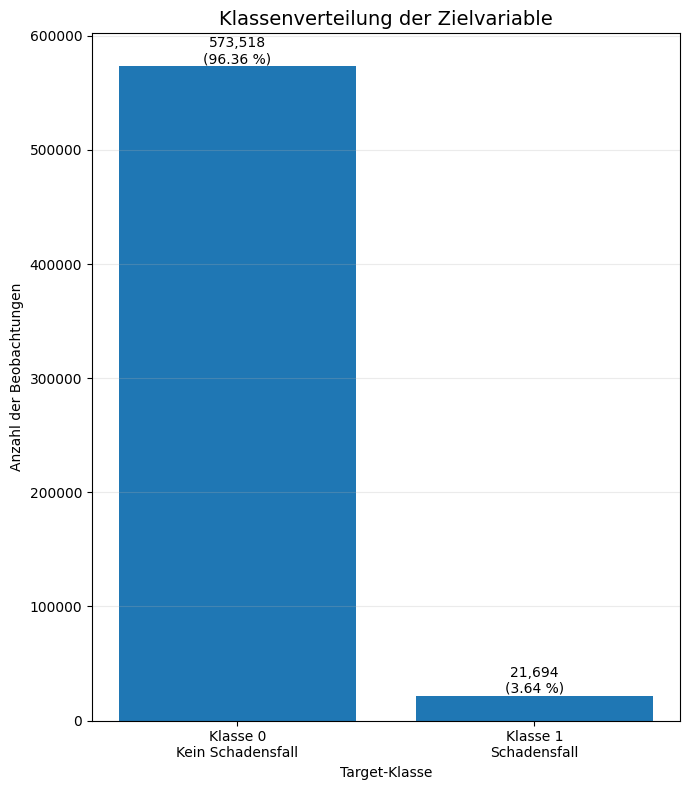

In [90]:
import matplotlib.pyplot as plt

class_counts = y.value_counts().sort_index()
class_percentages = y.value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(7, 8))

bars = ax.bar(
    ["Klasse 0\nKein Schadensfall", "Klasse 1\nSchadensfall"],
    class_counts.values
)

ax.set_title("Klassenverteilung der Zielvariable", fontsize=14)
ax.set_ylabel("Anzahl der Beobachtungen")
ax.set_xlabel("Target-Klasse")

# Werte über den Balken
for bar, count, percentage in zip(
    bars,
    class_counts.values,
    class_percentages.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f} %)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Visualisierung fehlender Werte

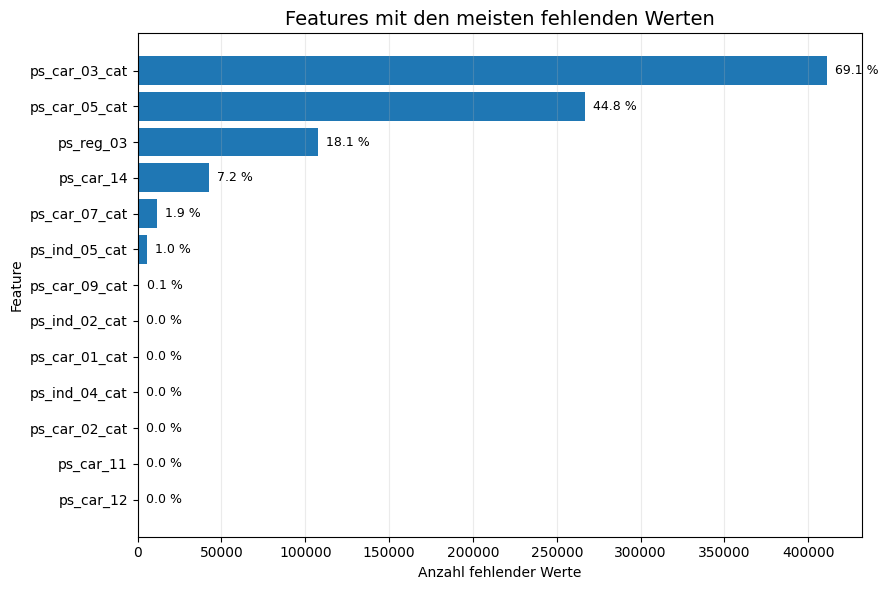

In [60]:
# Missing Values der ursprünglichen Daten
missing_counts = porto.data.isna().sum()

missing_counts = (
    missing_counts[missing_counts > 0]
    .sort_values(ascending=False)
    .head(15)
)

missing_percent = (
    missing_counts / len(porto.data) * 100
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    missing_counts.index[::-1],
    missing_counts.values[::-1]
)

ax.set_title(
    "Features mit den meisten fehlenden Werten",
    fontsize=14
)

ax.set_xlabel("Anzahl fehlender Werte")
ax.set_ylabel("Feature")

ax.grid(axis="x", alpha=0.25)

# Prozentwerte an die Balken schreiben
for bar, percentage in zip(
    bars,
    missing_percent.values[::-1]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {percentage:.1f} %",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ID entfernen

In [8]:
if "id" in X.columns:
    X = X.drop(columns=["id"])

## Feature-Typen erkennen

In [80]:
other_num_cols = [
    c for c in X.columns
    if c not in cat_cols
    and c not in bin_cols
] 

print("Categorical:", len(cat_cols))
print("Binary:", len(bin_cols))
print("Other numeric:", len(other_num_cols))
print("\nCategorical columns:")
print(cat_cols)

Categorical: 14
Binary: 17
Other numeric: 26

Categorical columns:
['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat']


### Real numeric features — Distributions

Real numeric features:
['ps_ind_01', 'ps_ind_03', 'ps_ind_14', 'ps_ind_15', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15']
Anzahl: 12


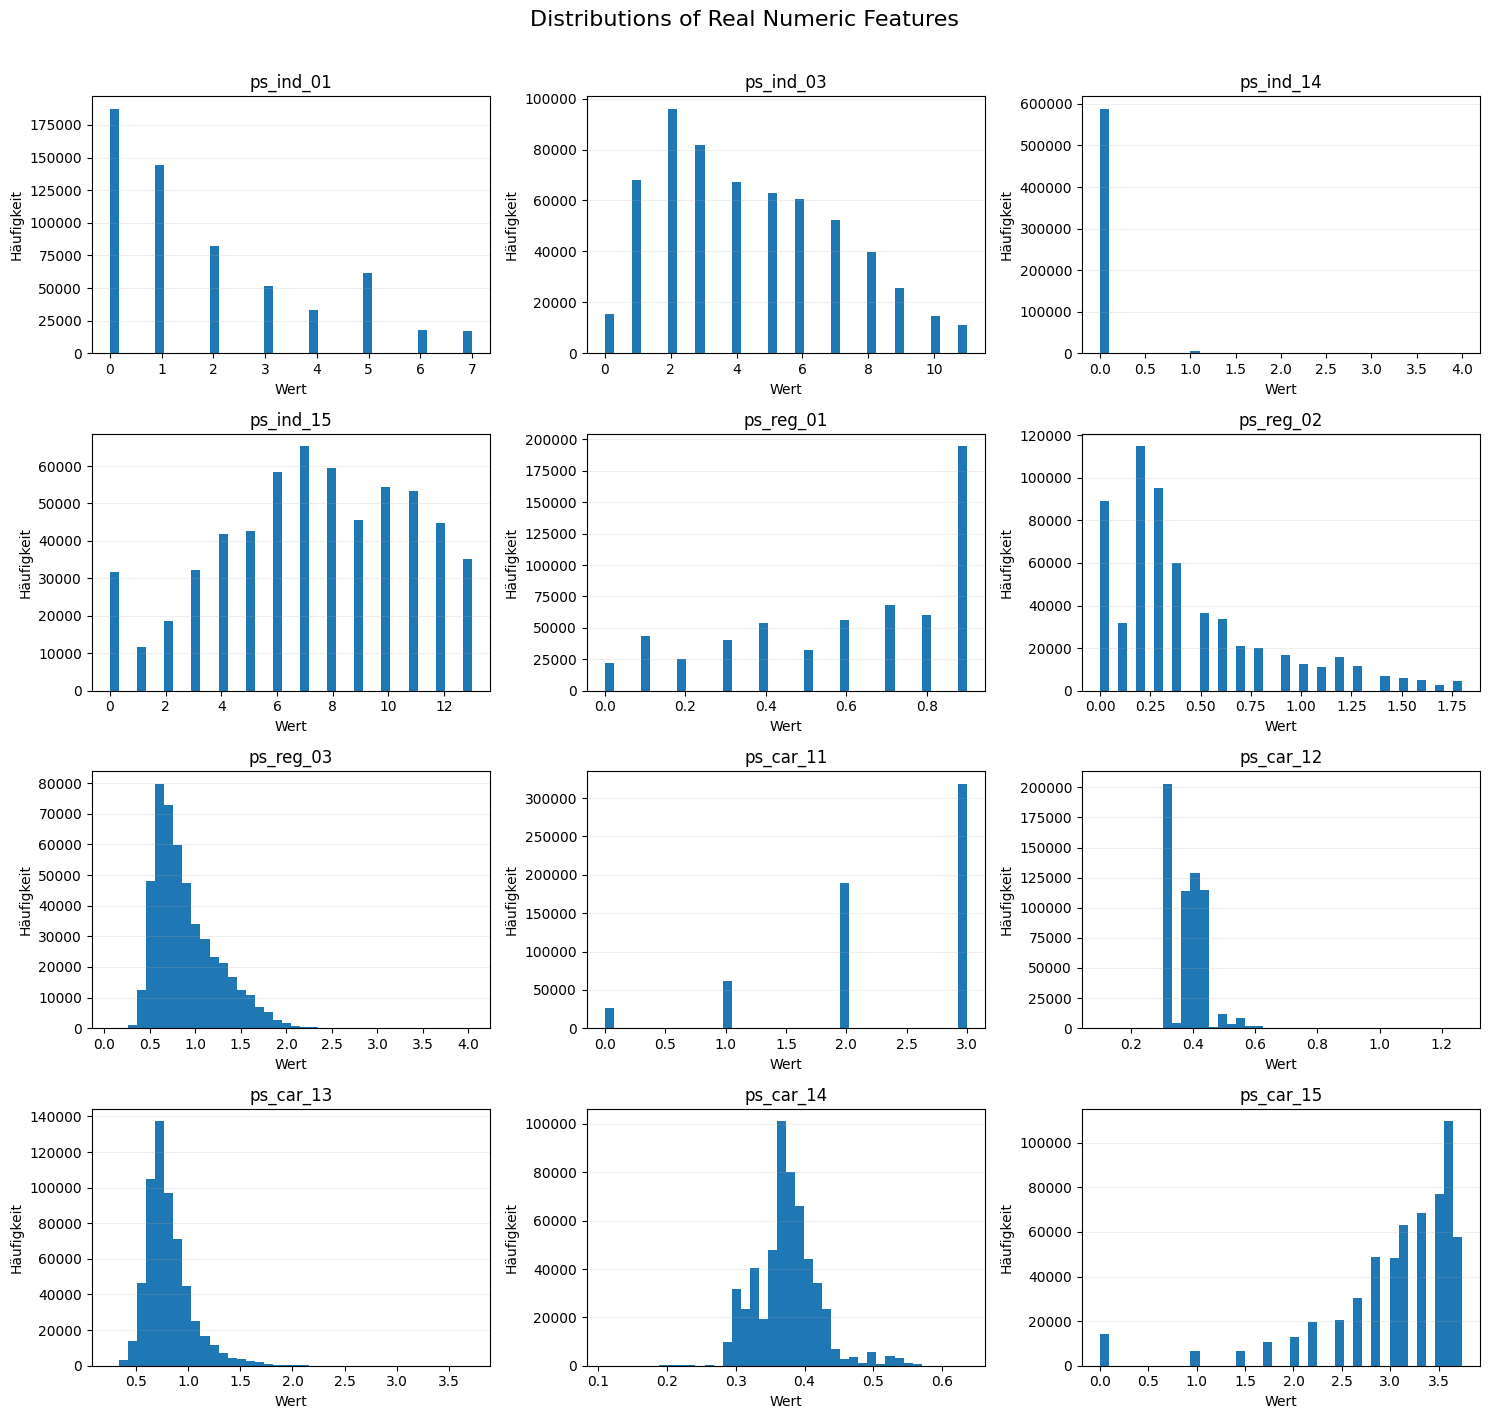

In [100]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

# Originaldaten für EDA verwenden
X_eda = porto.data.copy()

# Numerische Features, aber:
# - keine kategorialen (_cat)
# - keine binären (_bin)
# - keine ps_calc Features
real_numeric_cols = [
    c for c in X_eda.columns
    if not c.endswith("_cat")
    and not c.endswith("_bin")
    and not c.startswith("ps_calc_")
]

print("Real numeric features:")
print(real_numeric_cols)
print("Anzahl:", len(real_numeric_cols))

# In numerisches Format konvertieren
for col in real_numeric_cols:
    X_eda[col] = pd.to_numeric(
        X_eda[col],
        errors="coerce"
    )

# Plot
n_cols = 3
n_rows = math.ceil(len(real_numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 3.5 * n_rows)
)

axes = np.array(axes).flatten()

for ax, col in zip(axes, real_numeric_cols):

    data = X_eda[col].dropna()

    ax.hist(
        data,
        bins=40
    )

    ax.set_title(col)
    ax.set_xlabel("Wert")
    ax.set_ylabel("Häufigkeit")

    ax.grid(
        axis="y",
        alpha=0.2
    )

# Nicht verwendete Achsen entfernen
for ax in axes[len(real_numeric_cols):]:
    ax.remove()

fig.suptitle(
    "Distributions of Real Numeric Features",
    fontsize=16,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    "real_numeric_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ps_calc numeric features — Distributions

ps_calc numeric features:
['ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14']
Anzahl: 14


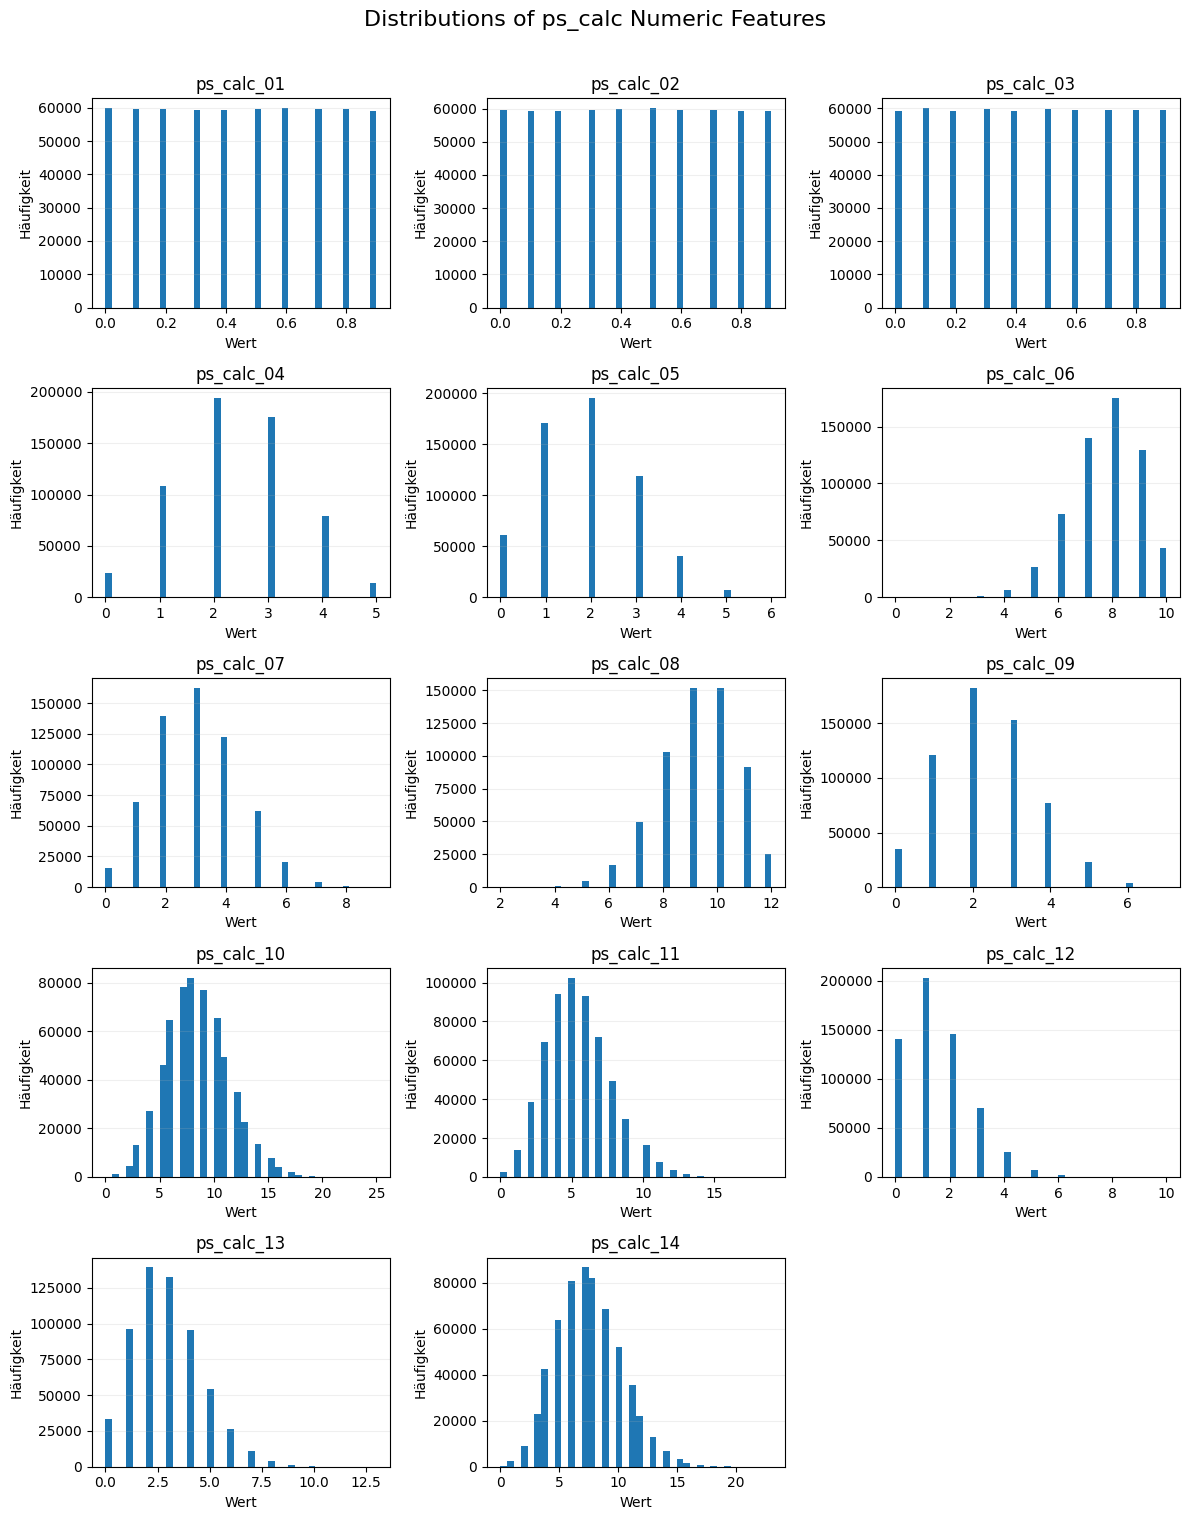

In [108]:
# Numerische ps_calc Features auswählen
calc_numeric_cols = [
    c for c in X_eda.columns
    if c.startswith("ps_calc_")
    and not c.endswith("_cat")
    and not c.endswith("_bin")
]

print("ps_calc numeric features:")
print(calc_numeric_cols)
print("Anzahl:", len(calc_numeric_cols))

# In numerisches Format konvertieren
for col in calc_numeric_cols:
    X_eda[col] = pd.to_numeric(
        X_eda[col],
        errors="coerce"
    )

n_cols = 3
n_rows = math.ceil(len(calc_numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 3 * n_rows)
)

axes = np.array(axes).flatten()

for ax, col in zip(axes, calc_numeric_cols):

    data = X_eda[col].dropna()

    ax.hist(
        data,
        bins=40
    )

    ax.set_title(col)
    ax.set_xlabel("Wert")
    ax.set_ylabel("Häufigkeit")

    ax.grid(
        axis="y",
        alpha=0.2
    )

for ax in axes[len(calc_numeric_cols):]:
    ax.remove()

fig.suptitle(
    "Distributions of ps_calc Numeric Features",
    fontsize=16,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    "ps_calc_numeric_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Missing Values richtig behandeln

In [12]:
# kategorial
for c in cat_cols:
    X[c] = X[c].astype("string")

    X[c] = X[c].replace({
        "-1": "MISSING",
        "-1.0": "MISSING"
    })

    X[c] = X[c].fillna("MISSING").astype(str)


# numerisch
for c in num_cols:
    X[c] = pd.to_numeric(
        X[c],
        errors="coerce"
    )

X[num_cols] = X[num_cols].replace(
    -1,
    np.nan
)

## Train-/Validation-Split

In [14]:
stratify=y

In [15]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_valid.shape)

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_valid.value_counts(normalize=True))

(476169, 57)
(119043, 57)

Train:
target
0    0.963553
1    0.036447
Name: proportion, dtype: float64

Validation:
target
0    0.963551
1    0.036449
Name: proportion, dtype: float64


## CatBoost

In [17]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",

    iterations=2000,
    learning_rate=0.03,
    depth=7,

    l2_leaf_reg=5,
    random_strength=1.0,

    random_seed=42,

    verbose=100,
    allow_writing_files=False
)

In [18]:
#Training
model.fit(
    X_train,
    y_train,

    cat_features=cat_cols,

    eval_set=(X_valid, y_valid),

    use_best_model=True,
    early_stopping_rounds=150
)

0:	test: 0.5109452	best: 0.5109452 (0)	total: 1.15s	remaining: 38m 13s
100:	test: 0.6289676	best: 0.6290234 (98)	total: 2m 12s	remaining: 41m 35s
200:	test: 0.6367852	best: 0.6367852 (200)	total: 4m 57s	remaining: 44m 25s
300:	test: 0.6388178	best: 0.6388178 (300)	total: 7m 42s	remaining: 43m 29s
400:	test: 0.6400171	best: 0.6400171 (400)	total: 10m 29s	remaining: 41m 49s
500:	test: 0.6407376	best: 0.6407376 (500)	total: 13m 15s	remaining: 39m 41s
600:	test: 0.6413053	best: 0.6413375 (584)	total: 16m	remaining: 37m 15s
700:	test: 0.6412618	best: 0.6413493 (673)	total: 18m 30s	remaining: 34m 17s
800:	test: 0.6413958	best: 0.6414000 (798)	total: 21m 3s	remaining: 31m 31s
900:	test: 0.6414914	best: 0.6414914 (900)	total: 23m 34s	remaining: 28m 45s
1000:	test: 0.6414643	best: 0.6416346 (927)	total: 26m 9s	remaining: 26m 6s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.6416345732
bestIteration = 927

Shrink model to first 928 iterations.


CatBoostClassifier(allow_writing_files=False, depth=7, eval_metric='AUC', iterations=2000, l2_leaf_reg=5, learning_rate=0.03, loss_function='Logloss', random_seed=42, random_strength=1.0, verbose=100)

## Gini berechnen

In [20]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss
)

p_valid = model.predict_proba(X_valid)[:, 1]

auc = roc_auc_score(
    y_valid,
    p_valid
)

gini = 2 * auc - 1

ap = average_precision_score(
    y_valid,
    p_valid
)

ll = log_loss(
    y_valid,
    p_valid
)

print(f"Normalized Gini:  {gini:.6f}")
print(f"ROC-AUC:          {auc:.6f}")
print(f"Average Precision:{ap:.6f}")
print(f"Log Loss:         {ll:.6f}")

print(
    "Best iteration:",
    model.get_best_iteration()
)

Normalized Gini:  0.283269
ROC-AUC:          0.641635
Average Precision:0.068500
Log Loss:         0.151723
Best iteration: 927


### ROC-Kurve

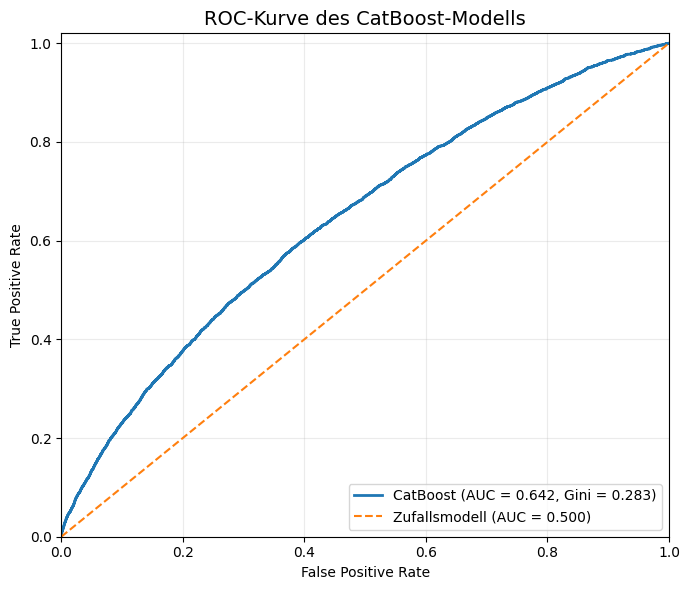

In [64]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_valid,
    p_valid
)

auc = roc_auc_score(
    y_valid,
    p_valid
)

gini = 2 * auc - 1

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"CatBoost (AUC = {auc:.3f}, Gini = {gini:.3f})"
)

# Zufallsmodell
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Zufallsmodell (AUC = 0.500)"
)

ax.set_title(
    "ROC-Kurve des CatBoost-Modells",
    fontsize=14
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

ax.legend(loc="lower right")

ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "roc_curve_catboost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Precision-Recall-Kurve

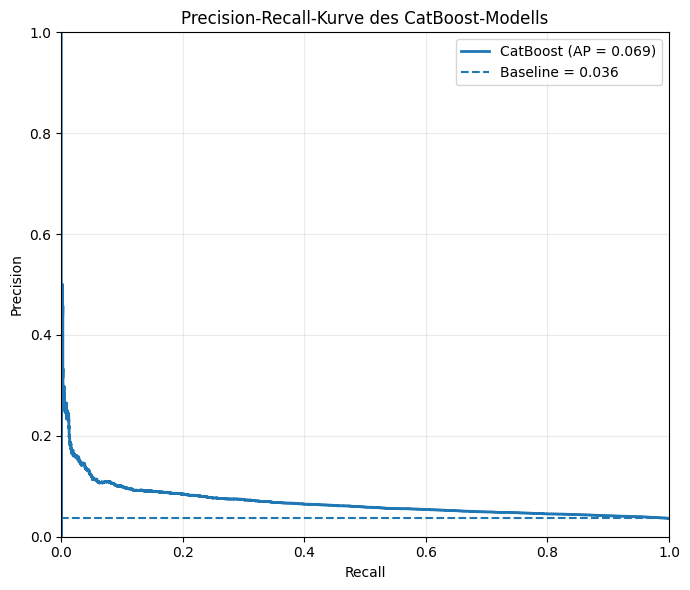

In [110]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_valid,
    p_valid
)

ap = average_precision_score(
    y_valid,
    p_valid
)

baseline = y_valid.mean()

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    recall,
    precision,
    linewidth=2,
    label=f"CatBoost (AP = {ap:.3f})"
)

ax.axhline(
    baseline,
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline = {baseline:.3f}"
)

ax.set_title("Precision-Recall-Kurve des CatBoost-Modells")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Eigene Gini-Funktion

In [22]:
from sklearn.metrics import roc_auc_score

def normalized_gini(y_true, y_score):
    auc = roc_auc_score(
        y_true,
        y_score
    )

    return 2 * auc - 1

In [23]:
gini = normalized_gini(
    y_valid,
    p_valid
)

print(
    f"Normalized Gini: {gini:.6f}"
)

Normalized Gini: 0.283269


## Feature Importance

In [25]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance":
        model.get_feature_importance()
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

,feature,importance
34,ps_car_13,8.687523
2,ps_ind_03,7.941871
20,ps_reg_03,6.681939
14,ps_ind_15,5.109045
4,ps_ind_05_cat,4.868093
19,ps_reg_02,3.950005
0,ps_ind_01,3.767581
18,ps_reg_01,3.740756
36,ps_car_15,3.472878
16,ps_ind_17_bin,3.303855


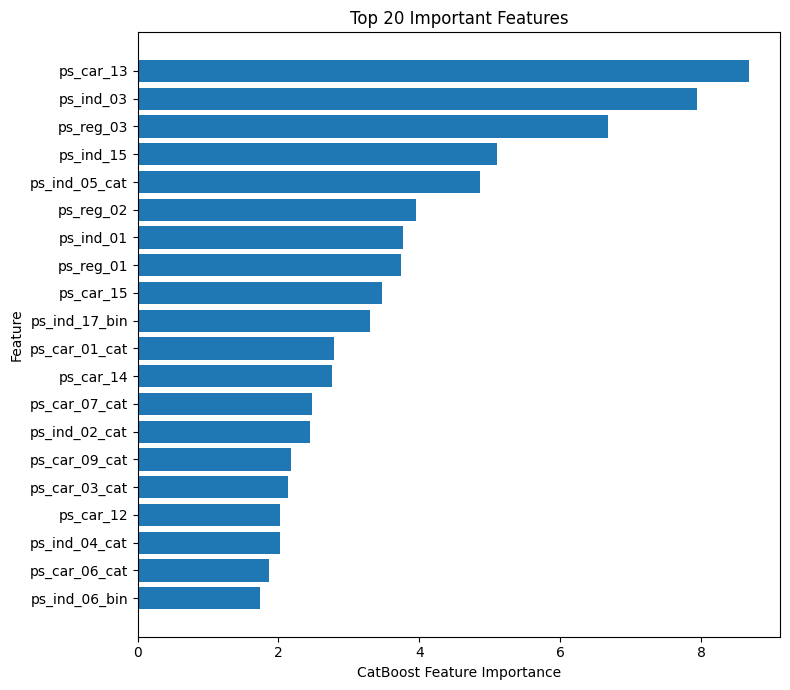

In [26]:
import matplotlib.pyplot as plt

top20 = (
    importance
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(8, 7))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.xlabel(
    "CatBoost Feature Importance"
)

plt.ylabel("Feature")

plt.title(
    "Top 20 Important Features"
)

plt.tight_layout()
plt.show()

## 5-fold Stratified Cross-Validation

In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import numpy as np
import pandas as pd

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_pred = np.zeros(len(X))

fold_results = []

for fold, (train_idx, valid_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print(f"\n========== Fold {fold} ==========")

    X_tr = X.iloc[train_idx].copy()
    X_va = X.iloc[valid_idx].copy()

    y_tr = y.iloc[train_idx]
    y_va = y.iloc[valid_idx]

    fold_model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",

        iterations=2000,
        learning_rate=0.03,
        depth=7,

        l2_leaf_reg=5,
        random_strength=1.0,

        random_seed=42 + fold,

        verbose=False,
        allow_writing_files=False
    )

    fold_model.fit(
        X_tr,
        y_tr,

        cat_features=cat_cols,

        eval_set=(X_va, y_va),

        use_best_model=True,
        early_stopping_rounds=150
    )

    pred = fold_model.predict_proba(
        X_va
    )[:, 1]

    oof_pred[valid_idx] = pred

    fold_auc = roc_auc_score(
        y_va,
        pred
    )

    fold_gini = (
        2 * fold_auc - 1
    )

    fold_results.append({
        "fold": fold,
        "roc_auc": fold_auc,
        "normalized_gini":
            fold_gini,
        "best_iteration":
            fold_model.get_best_iteration()
    })

    print(
        f"Gini = {fold_gini:.6f}"
    )


========== Fold 1 ==========
Gini = 0.290971

========== Fold 2 ==========
Gini = 0.283319

========== Fold 3 ==========
Gini = 0.281085

========== Fold 4 ==========
Gini = 0.283049

========== Fold 5 ==========
Gini = 0.270625


In [29]:
cv_results = pd.DataFrame(
    fold_results
)

display(cv_results)

mean_gini = (
    cv_results[
        "normalized_gini"
    ].mean()
)

std_gini = (
    cv_results[
        "normalized_gini"
    ].std()
)

oof_auc = roc_auc_score(
    y,
    oof_pred
)

oof_gini = 2 * oof_auc - 1

print(
    f"Mean CV Gini: {mean_gini:.6f}"
)

print(
    f"Std CV Gini:  {std_gini:.6f}"
)

print(
    f"OOF Gini:     {oof_gini:.6f}"
)

,fold,roc_auc,normalized_gini,best_iteration
0,1,0.645486,0.290971,781
1,2,0.641659,0.283319,1321
2,3,0.640542,0.281085,860
3,4,0.641525,0.283049,1329
4,5,0.635312,0.270625,900


Mean CV Gini: 0.281810
Std CV Gini:  0.007304
OOF Gini:     0.281671


### Visualisierung der Cross-Validation-Ergebnisse

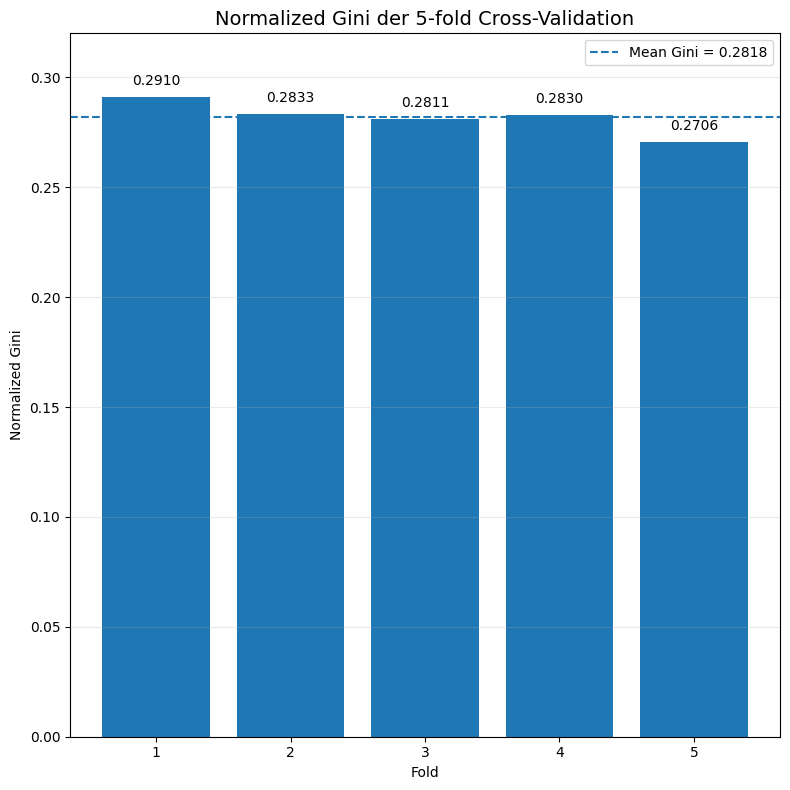

In [97]:
import matplotlib.pyplot as plt

# Gini-Werte aus den bereits berechneten CV-Ergebnissen
folds = cv_results["fold"]
gini_values = cv_results["normalized_gini"]

mean_gini = gini_values.mean()

fig, ax = plt.subplots(figsize=(8, 8))

bars = ax.bar(
    folds.astype(str),
    gini_values
)

# Mittelwert als gestrichelte Linie
ax.axhline(
    mean_gini,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean Gini = {mean_gini:.4f}"
)

# Gini-Wert über jedem Balken
for bar, value in zip(bars, gini_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.004,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title(
    "Normalized Gini der 5-fold Cross-Validation",
    fontsize=14
)

ax.set_xlabel("Fold")
ax.set_ylabel("Normalized Gini")

# Start bei 0, damit die Unterschiede nicht künstlich übertrieben wirken
ax.set_ylim(0, 0.32)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()

plt.tight_layout()

# Für das Portfolio speichern
plt.savefig(
    "cv_gini_folds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [112]:
final_results = pd.DataFrame({
    "Evaluation": [
        "Hold-out Validation",
        "5-Fold CV Mean",
        "Out-of-Fold"
    ],
    "Normalized Gini": [
        gini,
        mean_gini,
        oof_gini
    ],
    "ROC-AUC": [
        auc,
        (mean_gini + 1) / 2,
        (oof_gini + 1) / 2
    ]
})

final_results

,Evaluation,Normalized Gini,ROC-AUC
0,Hold-out Validation,0.283269,0.641635
1,5-Fold CV Mean,0.281810,0.640905
2,Out-of-Fold,0.281671,0.640835


### Vergleich mit einer No-Skill-Baseline

In [119]:
baseline_results = pd.DataFrame({
    "Modell / Verfahren": [
        "No-Skill / Random Ranking",
        "CatBoost Hold-out",
        "CatBoost 5-Fold CV"
    ],
    "ROC-AUC": [
        0.5,
        auc,
        (mean_gini + 1) / 2
    ],
    "Normalized Gini": [
        0.0,
        gini,
        mean_gini
    ]
})

baseline_results["ROC-AUC"] = (
    baseline_results["ROC-AUC"]
    .round(6)
)

baseline_results["Normalized Gini"] = (
    baseline_results["Normalized Gini"]
    .round(6)
)

display(baseline_results)

,Modell / Verfahren,ROC-AUC,Normalized Gini
0,No-Skill / Random Ranking,0.500000,0.000000
1,CatBoost Hold-out,0.641635,0.283269
2,CatBoost 5-Fold CV,0.640905,0.281810


In [30]:
cv_results.to_csv(
    "catboost_cv_results.csv",
    index=False
)

importance.to_csv(
    "catboost_feature_importance.csv",
    index=False
)

model.save_model(
    "catboost_porto_seguro.cbm"
)

In [31]:
print(X.shape)
print(y.value_counts())
print(y.value_counts(normalize=True))

(595212, 57)
target
0    573518
1     21694
Name: count, dtype: int64
target
0    0.963552
1    0.036448
Name: proportion, dtype: float64


In [116]:
final_results.to_csv(
    "final_results.csv",
    index=False
)

### Save results : 

In [19]:
import json
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_ID = "03"

all_results = [
    {
        "model": "CatBoost",
        "auc": 0.6416,
        "gini": 0.2833,
        "ap": 0.0685,
        "base_rate": 0.0364,
        "params": {
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "iterations": 2000,
            "learning_rate": 0.03,
            "depth": 7,
            "l2_leaf_reg": 5,
            "random_strength": 1.0,
            "random_seed": 42,
            "best_iteration": 927,
        },
        "notes": "hold-out, with calc (5-fold CV: gini 0.2818)",
    },
]

path = RESULTS_DIR / f"{NOTEBOOK_ID}_models.json"
with open(path, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Results saved in {path}")


Results saved in ../results/03_models.json


### Without CALC : 

In [2]:
# ============================================================
# STANDALONE — CatBoost with and without the ps_calc block
# Reloads the data, rebuilds the preprocessing and the split,
# trains both variants and exports to ../results/03_models.json
# ============================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from catboost import CatBoostClassifier

RANDOM_STATE = 42

# --- 1. Load ------------------------------------------------
porto = fetch_openml(data_id=42742, as_frame=True, parser="auto")
X_full = porto.frame.drop(columns=["target"]).copy()
y_full = pd.to_numeric(porto.frame["target"], errors="raise").astype(int)

if "id" in X_full.columns:
    X_full = X_full.drop(columns=["id"])

cat_cols_all = [c for c in X_full.columns if c.endswith("_cat")]
bin_cols_all = [c for c in X_full.columns if c.endswith("_bin")]
num_cols_all = [c for c in X_full.columns
                if c not in cat_cols_all + bin_cols_all]

# --- 2. Same missing-value handling as above ----------------
for c in cat_cols_all:
    X_full[c] = X_full[c].astype("string")
    X_full[c] = X_full[c].replace({"-1": "MISSING", "-1.0": "MISSING"})
    X_full[c] = X_full[c].fillna("MISSING").astype(str)

for c in num_cols_all:
    X_full[c] = pd.to_numeric(X_full[c], errors="coerce")
X_full[num_cols_all] = X_full[num_cols_all].replace(-1, np.nan)

# Binary columns also arrive as 'category' dtype from OpenML;
# CatBoost rejects any category column not listed in cat_features.
for c in bin_cols_all:
    X_full[c] = pd.to_numeric(X_full[c], errors="coerce")

print(X_full.dtypes.value_counts())   # no 'category' left except the _cat ones

# --- 3. Same configuration as the model above ---------------
CB_PARAMS = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=2000,
    learning_rate=0.03,
    depth=7,
    l2_leaf_reg=5,
    random_strength=1.0,
    random_seed=RANDOM_STATE,
    verbose=200,
    allow_writing_files=False,
)

def run(X, label):
    """Train CatBoost on the given feature set and return its metrics."""
    cats = [c for c in cat_cols_all if c in X.columns]
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y_full, test_size=0.20, stratify=y_full,
        random_state=RANDOM_STATE)

    m = CatBoostClassifier(**CB_PARAMS)
    m.fit(X_tr, y_tr, cat_features=cats, eval_set=(X_va, y_va),
          use_best_model=True, early_stopping_rounds=150)

    p = m.predict_proba(X_va)[:, 1]
    auc = roc_auc_score(y_va, p)
    ap = average_precision_score(y_va, p)
    print(f"\n{label}: {X.shape[1]} features | best iteration "
          f"{m.get_best_iteration()}")
    print(f"  AUC {auc:.6f} | Gini {2*auc-1:.6f} | AP {ap:.6f}")
    return auc, ap, int(m.get_best_iteration()), float(y_va.mean())

# --- 4. Both variants ---------------------------------------
calc_cols = [c for c in X_full.columns if "calc" in c]
X_nc = X_full.drop(columns=calc_cols)
print(f"{len(calc_cols)} calc columns identified\n")

auc_w, ap_w, it_w, base = run(X_full, "WITH calc")
auc_n, ap_n, it_n, _    = run(X_nc,   "WITHOUT calc")

print(f"\nDelta Gini (without - with): {(2*auc_n-1) - (2*auc_w-1):+.4f}")

# --- 5. Export ----------------------------------------------
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def entry(auc, ap, best_it, notes):
    return {"model": "CatBoost",
            "auc": round(float(auc), 4),
            "gini": round(float(2 * auc - 1), 4),
            "ap": round(float(ap), 4),
            "base_rate": round(base, 4),
            "params": {**{k: v for k, v in CB_PARAMS.items()
                          if k not in ("verbose", "allow_writing_files")},
                       "best_iteration": best_it,
                       "early_stopping_rounds": 150},
            "notes": notes}

all_results = [
    entry(auc_w, ap_w, it_w, "hold-out 80/20, with calc"),
    entry(auc_n, ap_n, it_n, "hold-out 80/20, without calc"),
]

path = RESULTS_DIR / "03_models.json"
with open(path, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"\nSaved to {path}\n")
for r in all_results:
    print(f"CatBoost | {r['notes']:<30} | Gini {r['gini']:.4f} | AP {r['ap']:.4f}")

float64    26
int64      17
str        14
Name: count, dtype: int64
20 calc columns identified

0:	test: 0.5109452	best: 0.5109452 (0)	total: 208ms	remaining: 6m 56s
200:	test: 0.6367665	best: 0.6367665 (200)	total: 34.1s	remaining: 5m 5s
400:	test: 0.6397924	best: 0.6398326 (394)	total: 1m 12s	remaining: 4m 49s
600:	test: 0.6413205	best: 0.6413205 (600)	total: 1m 52s	remaining: 4m 21s
800:	test: 0.6416331	best: 0.6417912 (731)	total: 2m 33s	remaining: 3m 49s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.6417911613
bestIteration = 731

Shrink model to first 732 iterations.

WITH calc: 57 features | best iteration 731
  AUC 0.641791 | Gini 0.283582 | AP 0.068587
0:	test: 0.5509352	best: 0.5509352 (0)	total: 142ms	remaining: 4m 44s
200:	test: 0.6361194	best: 0.6361713 (199)	total: 31.9s	remaining: 4m 45s
400:	test: 0.6403874	best: 0.6403874 (400)	total: 1m 7s	remaining: 4m 29s
600:	test: 0.6422063	best: 0.6422290 (579)	total: 1m 45s	remaining: 4m 5s
800:	test: 0.64